# Cleaning Method for AEMO Data

This notebook steps through the cleaning methods needed to transform the raw AEMO data into a useable dataset to be imported into Microsoft Power BI. It is informed by findings from the 01_exploration notebook. The stable functions live in src/transform.py

It also calculates a number of features that will be used in the analysis

### Cleaning Decisions Summary
- renaming columns to more user friendly names
- explicitly casting data types
- standardising timezone to AEST no DST as per AEMO


                       - canonical column names + types
                       - canonical timezone (NEM time, AEST no DST)
                       - duplicates: drop, keeping last
                       - missing intervals: flag, don't fill
                       - spike threshold: $300/MWh (justify)
                       - features to engineer (list)

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path().resolve().parent / "src"))

In [2]:
import pandas as pd
import matplotlib as plt
from config import PROCESSED_DIR
import seaborn as sns
import numpy as np

In [3]:
historical = pd.read_parquet(PROCESSED_DIR / "historical_price_demand.parquet")

The column names as provided by AEMO are not intuitive. They've been replaced here, and units of measurement are included in the header

In [4]:
from transform import rename_cols

historical = rename_cols(historical)
print(historical)


        State     Settlement Date  Demand (MW)  Price ($/MWh) PERIODTYPE
0        NSW1 2024-01-01 00:05:00      6574.92          57.98      TRADE
1        NSW1 2024-01-01 00:10:00      6651.09          70.27      TRADE
2        NSW1 2024-01-01 00:15:00      6538.96          57.98      TRADE
3        NSW1 2024-01-01 00:20:00      6497.99          54.95      TRADE
4        NSW1 2024-01-01 00:25:00      6404.55          54.95      TRADE
...       ...                 ...          ...            ...        ...
1052635  VIC1 2025-12-31 23:40:00      4242.66           8.95      TRADE
1052636  VIC1 2025-12-31 23:45:00      4218.78           8.95      TRADE
1052637  VIC1 2025-12-31 23:50:00      4201.52           8.95      TRADE
1052638  VIC1 2025-12-31 23:55:00      4162.44           1.01      TRADE
1052639  VIC1 2026-01-01 00:00:00      4136.51          64.46      TRADE

[1052640 rows x 5 columns]


From the exploration step, the "PERIODTYPE" column contains only one value, "Trade." It is not useful information and is removed. 

In [5]:
from transform import drop_redundant_cols
print(historical["PERIODTYPE"].unique())
historical = drop_redundant_cols(historical)
print(historical.columns)

<ArrowStringArray>
['TRADE']
Length: 1, dtype: str
Index(['State', 'Settlement Date', 'Demand (MW)', 'Price ($/MWh)'], dtype='str')


This step explicity converts data types so that numerical columns are floats, dates are datetime and the State is category

In [6]:
from transform import cast_types
print(historical.dtypes)
historical = cast_types(historical)
print(f"\n{historical.dtypes}")

State                         str
Settlement Date    datetime64[us]
Demand (MW)               float64
Price ($/MWh)             float64
dtype: object

State                    category
Settlement Date    datetime64[us]
Demand (MW)               float64
Price ($/MWh)             float64
dtype: object


AEMO Time is AEST without Daylight Saving. Pandas imports as US datetime, so this needs to be converted

In [7]:
from transform import standardise_timezone
print(historical["Settlement Date"].dtype)
historical = standardise_timezone(historical)
print(historical["Settlement Date"].dtype)

datetime64[us]
datetime64[us, Australia/Brisbane]


We need to check whether there are missing dates in our time series, and decide how to handle them. As the data contains duplicate time stamps per State, we need to loop through each state

In [8]:
from transform import flag_missing_time_intervals
historical = flag_missing_time_intervals(historical)

To aid analysis, a number of features can be engineered from the timestamp in "Date" column. 
hour of day, day of week, day name, month, season, year, weekend flag, public-holiday flag (optional)

In [9]:
from transform import date_features
print(historical.head(2))
historical = date_features(historical)

print(f"\n******************************************")
print(f"\n{historical.head(5)}")
print(f"\n{historical.tail(5)}")

            Settlement Date State  Demand (MW)  Price ($/MWh)  is_imputed
0 2024-01-01 00:05:00+10:00  NSW1      6574.92          57.98       False
1 2024-01-01 00:10:00+10:00  NSW1      6651.09          70.27       False

******************************************

            Settlement Date State  Demand (MW)  Price ($/MWh)  is_imputed  \
0 2024-01-01 00:05:00+10:00  NSW1      6574.92          57.98       False   
1 2024-01-01 00:10:00+10:00  NSW1      6651.09          70.27       False   
2 2024-01-01 00:15:00+10:00  NSW1      6538.96          57.98       False   
3 2024-01-01 00:20:00+10:00  NSW1      6497.99          54.95       False   
4 2024-01-01 00:25:00+10:00  NSW1      6404.55          54.95       False   

         Date      Time  Hour of Day Day Name  Weekday  Month Month Name  \
0  2024-01-01  00:05:00            0   Monday        0      1    January   
1  2024-01-01  00:10:00            0   Monday        0      1    January   
2  2024-01-01  00:15:00            0   Mon

In [10]:
from transform import spike
historical = spike(historical)
print(historical["Is Spike"].value_counts())

Is Spike
False    1037725
True       14915
Name: count, dtype: int64


In [11]:
# from transform import add_rolling_features
# historical = add_rolling_features(historical, col="Price ($/MWh)", aggs=["mean", "std", "max", "min"], windows={"24h": "1D", "7d": "7D","30d":"30D"})
# print(historical)
NSW = historical[historical["State"]== "NSW1"]
NSW = NSW.set_index(["Settlement Date"])
NSW = NSW.sort_index()

In [12]:
NSW["Rolling 24hr"]= NSW.rolling("1D")["Price ($/MWh)"].mean()
NSW["Rolling 1hr"]= NSW.rolling("1h")["Price ($/MWh)"].mean()
print(NSW['Rolling 1hr'])

Settlement Date
2024-01-01 00:05:00+10:00    57.980000
2024-01-01 00:10:00+10:00    64.125000
2024-01-01 00:15:00+10:00    62.076667
2024-01-01 00:20:00+10:00    60.295000
2024-01-01 00:25:00+10:00    59.226000
                               ...    
2025-12-31 23:40:00+10:00    58.683333
2025-12-31 23:45:00+10:00    59.514167
2025-12-31 23:50:00+10:00    61.098333
2025-12-31 23:55:00+10:00    62.006667
2026-01-01 00:00:00+10:00    63.722500
Name: Rolling 1hr, Length: 210528, dtype: float64


In [16]:
def add_rolling_features(df: pd.DataFrame, col: str, windows: list[str], aggs: list[str] = ("mean",),) -> pd.DataFrame:
    """calculates a range of rolling statistics over different time periods"""
    df = df.sort_values(["State", "Settlement Date"]).reset_index(drop=True)
    grouped = df.groupby("State", observed=True)

    for window in windows:
        min_period = pd.Timedelta(window) // pd.Timedelta("5min")
        for agg in aggs:
            rolled = (
                grouped.rolling(window, on="Settlement Date", min_periods=min_period)[col]
                .agg(agg)
                .reset_index(level=0, drop=True)
                .reset_index(drop=True)
            )
            df[f"Rolling {window} {agg.title()} {col}"] = rolled
    return df

df = add_rolling_features(historical, "Price ($/MWh)", ["1h","1D", "7D", "30D"], aggs=["mean", "std", "min", "max"])
df.to_csv("test.csv")

12
288
2016
8640


In [17]:
nsw = df[df["State"]=="NSW1"]
# nsw.set_index("Settlement Date")
print(nsw)

                 Settlement Date State  Demand (MW)  Price ($/MWh)  \
0      2024-01-01 00:05:00+10:00  NSW1      6574.92          57.98   
1      2024-01-01 00:10:00+10:00  NSW1      6651.09          70.27   
2      2024-01-01 00:15:00+10:00  NSW1      6538.96          57.98   
3      2024-01-01 00:20:00+10:00  NSW1      6497.99          54.95   
4      2024-01-01 00:25:00+10:00  NSW1      6404.55          54.95   
...                          ...   ...          ...            ...   
210523 2025-12-31 23:40:00+10:00  NSW1      6815.60          58.19   
210524 2025-12-31 23:45:00+10:00  NSW1      6747.40          68.25   
210525 2025-12-31 23:50:00+10:00  NSW1      6787.87          77.33   
210526 2025-12-31 23:55:00+10:00  NSW1      6751.40          67.93   
210527 2026-01-01 00:00:00+10:00  NSW1      6777.74          77.89   

        is_imputed        Date      Time  Hour of Day   Day Name  Weekday  \
0            False  2024-01-01  00:05:00            0     Monday        0   
1    

<Figure size 640x480 with 0 Axes>

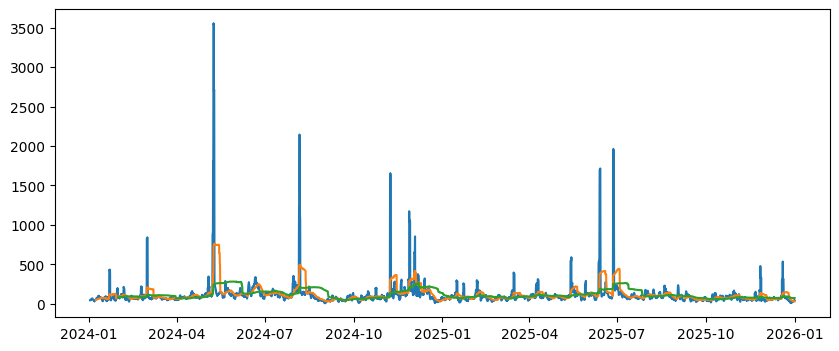

In [31]:
import matplotlib.pyplot as plt
fig = plt.figure()            
fig, ax = plt.subplots(figsize=(10, 4))

# ax.plot(nsw["Settlement Date"], nsw["Price ($/MWh)"])
# ax.plot(nsw["Settlement Date"], nsw["Rolling 1h Mean Price ($/MWh)"])
ax.plot(nsw["Settlement Date"], nsw["Rolling 1D Mean Price ($/MWh)"])
ax.plot(nsw["Settlement Date"], nsw["Rolling 7D Mean Price ($/MWh)"])
ax.plot(nsw["Settlement Date"], nsw["Rolling 30D Mean Price ($/MWh)"])